# Filter Methods: Mutual Information (MI) for Feature Selection

![Mutual Information Venn Diagram](https://tse1.mm.bing.net/th/id/OIP.JcjBTeFPKBM9r9Ho6R9jYQHaFO?r=0&cb=thfc1falcon&rs=1&pid=ImgDetMain&o=7&rm=3)

*Image: A Venn diagram illustrating how Mutual Information $I(X;Y)$ represents the shared information (intersection) between the entropy of X $H(X)$ and the entropy of Y $H(Y)$.*

### 1. Clear Overview
Information theoretic measures provide a robust framework for quantifying the dependency between variables. The core metric, **Mutual Information (MI)**, quantifies the reduction in uncertainty about a target variable $Y$ given knowledge of a feature $X$.

Unlike Pearson’s (linear) or Spearman’s (monotonic) correlation, **MI is capable of capturing any arbitrary dependency**, making it an essential filter method for complex, real-world datasets.

### 2. Theoretical Foundations
* **Entropy $H(Y)$**: A measure of randomness or unpredictability in the target variable.
* **Mutual Information $I(X; Y)$**: Measures how much the uncertainty of $Y$ is reduced by knowing $X$.

$$I(X; Y) = H(Y) - H(Y|X)$$

*If $I(X; Y)$ is large, $X$ is highly informative. If it is 0, they are strictly independent.*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

sns.set_theme(style="whitegrid")

### 3. Generating Synthetic Data: The "Blind Spot" Test
We will generate a target variable `y` that is heavily dependent on three distinct features:
1.  `Linear_Feature`: A standard proportional relationship.
2.  `Quadratic_Feature`: A perfect U-shaped curve (non-linear, non-monotonic).
3.  `Noise_Feature`: Pure random static.

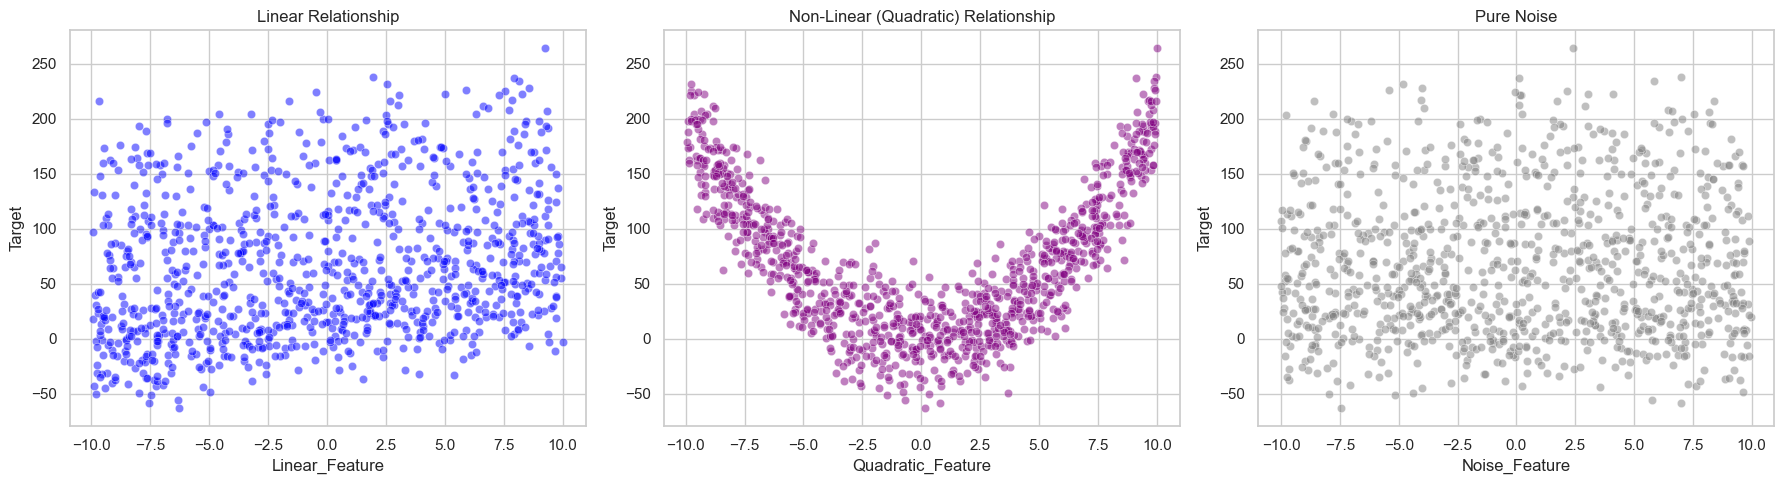

In [2]:
np.random.seed(42)
n_samples = 1000

X_linear = np.random.uniform(-10, 10, n_samples)
X_quadratic = np.random.uniform(-10, 10, n_samples)
X_noise = np.random.uniform(-10, 10, n_samples)

# Target has a linear dependence on Feature 1, and a non-linear dependence on Feature 2
y = (3 * X_linear) + (2 * X_quadratic**2) + np.random.normal(0, 20, n_samples)

df = pd.DataFrame({
    'Linear_Feature': X_linear,
    'Quadratic_Feature': X_quadratic,
    'Noise_Feature': X_noise,
    'Target': y
})

# Let's visualize the relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='Linear_Feature', y='Target', data=df, ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title("Linear Relationship")

sns.scatterplot(x='Quadratic_Feature', y='Target', data=df, ax=axes[1], color='purple', alpha=0.5)
axes[1].set_title("Non-Linear (Quadratic) Relationship")

sns.scatterplot(x='Noise_Feature', y='Target', data=df, ax=axes[2], color='gray', alpha=0.5)
axes[2].set_title("Pure Noise")

plt.tight_layout()
plt.show()

### 4. Implementation: Pearson vs. Mutual Information
Now we apply both Pearson Correlation and Mutual Information to the dataset. We expect Pearson to successfully identify the `Linear_Feature` but completely fail on the `Quadratic_Feature`. MI should correctly identify *both* informative features.

In [3]:
# 1. Calculate Absolute Pearson Correlation
pearson_scores = df.corr()['Target'].drop('Target').abs()

# 2. Calculate Mutual Information (Regression)
X = df.drop(columns=['Target'])
mi_array = mutual_info_regression(X, df['Target'], random_state=42)
mi_scores = pd.Series(mi_array, index=X.columns)

# 3. Combine into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Pearson_Score (Linear)': pearson_scores,
    'MI_Score (Any Pattern)': mi_scores
})

# Normalize scores between 0 and 1 for side-by-side visual comparison
comparison_df_normalized = comparison_df / comparison_df.max()

display(comparison_df.round(4))

,Pearson_Score (Linear),MI_Score (Any Pattern)
Linear_Feature,0.2240,0.0398
Quadratic_Feature,0.0132,0.8454
Noise_Feature,0.0228,0.0007


### 5. Visualization and Application Summary

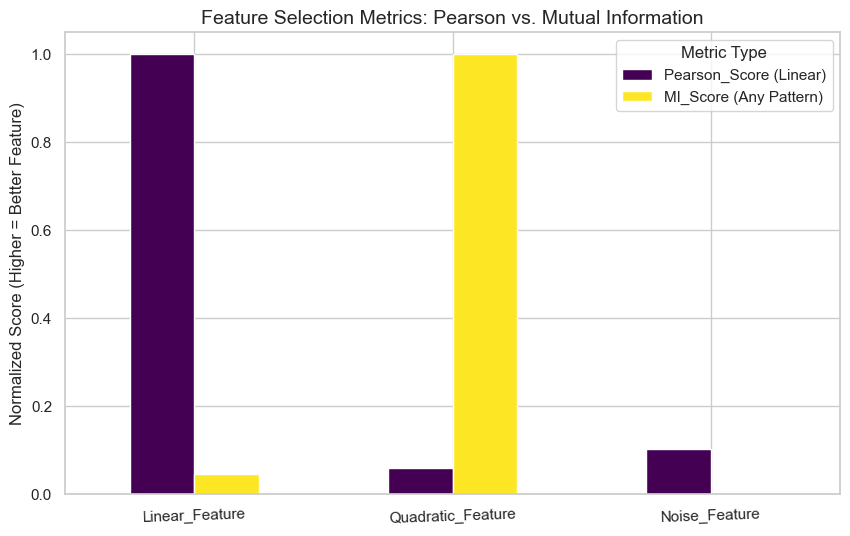


--- ACTIONABLE INSIGHT ---
1. Linear Feature: Both Pearson and MI recognize it as highly predictive.
2. Quadratic Feature: Pearson scores it near ZERO because there is no straight-line fit. Mutual Information successfully detects the massive reduction in entropy and scores it highly.
3. Noise Feature: Both metrics correctly ignore it.

Conclusion: Always supplement correlation-based filters with Mutual Information to catch non-linear signals!


In [10]:
# Plotting the normalized comparison
comparison_df_normalized.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='white')
plt.title("Feature Selection Metrics: Pearson vs. Mutual Information", fontsize=14)
plt.ylabel("Normalized Score (Higher = Better Feature)")
plt.xticks(rotation=2)
plt.legend(title="Metric Type")
plt.show()

print("\n--- ACTIONABLE INSIGHT ---")
print("1. Linear Feature: Both Pearson and MI recognize it as highly predictive.")
print("2. Quadratic Feature: Pearson scores it near ZERO because there is no straight-line fit. "
      "Mutual Information successfully detects the massive reduction in entropy and scores it highly.")
print("3. Noise Feature: Both metrics correctly ignore it.")
print("\nConclusion: Always supplement correlation-based filters with Mutual Information to catch non-linear signals!")